# Combine All Years Wikipedia Popularity Dataset

This notebook downloads all yearly Wikipedia pageviews datasets from HuggingFace (`Cyro1/enwiki_pageviews_Year_m`) and combines them into a single dataset with multi-year averages for both popularity and rank.

## Setup: Imports and Configuration

In [ ]:
import sys
sys.path.insert(0, "..")

import os
import pandas as pd
from datasets import load_dataset
from tqdm import tqdm
from pathlib import Path
from dotenv import load_dotenv
from config import DATA_DIR, CACHE_DIR

# Load environment variables
load_dotenv()

# Configuration
YEARS = [2020, 2021, 2022, 2023]  # Years to combine
OUTPUT_PATH = Path(DATA_DIR) / "combined_all_years_popularity.parquet"
INPUT_HUGGINGFACE_REPO_BASE = "Cyro1/enwiki_pageviews_YEAR_m"
HUGGINGFACE_REPO_ID = "Cyro1/enwiki_pageviews_m"  # Multi-year combined dataset
HF_TOKEN = os.getenv("HUGGINGFACE_TOKEN")

print(f"Will combine data from years: {YEARS}")
print(f"Output will be saved to: {OUTPUT_PATH}")
print(f"HuggingFace repo: {HUGGINGFACE_REPO_ID}")

/Users/cyro/Documents/VSC/PopularityBias/venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Will combine data from years: [2020, 2021, 2022, 2023]
Output will be saved to: /Users/cyro/Documents/VSC/PopularityBias/data/combined_all_years_popularity.parquet
HuggingFace repo: Cyro1/enwiki_pageviews_m


## Step 1: Download All Datasets from HuggingFace

Download each yearly dataset from HuggingFace Hub. Each dataset contains the monthly average pageviews for that year.

In [ ]:
datasets = {}

for year in YEARS:

    repo_name = INPUT_HUGGINGFACE_REPO_BASE.replace("YEAR", str(year))
    print(f"\nLoading {repo_name}...")
    
    try:
        # Load train+test splits combined
        ds = load_dataset(
            repo_name,
            split="train+test",
            cache_dir=CACHE_DIR
        )
        datasets[year] = ds
        print(f"  ✓ Loaded {len(ds):,} articles from {year}")
        
        # Show first example
        print(f"  Columns: {ds.column_names}")
        print(f"  Sample: {ds[0]}")
        
    except Exception as e:
        print(f"  ✗ Error loading {year}: {e}")
        print(f"  Skipping {year}...")

print(f"\n✓ Successfully loaded {len(datasets)} datasets")


Loading Cyro1/enwiki_pageviews_2020_m...


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/236M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/26.2M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/5313177 [00:00<?, ? examples/s]

...

data/train-00000-of-00001.parquet:   0%|          | 0.00/235M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/26.1M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/5313177 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/590353 [00:00<?, ? examples/s]

  ✓ Loaded 5,903,530 articles from 2023
  Columns: ['wikipedia_id', 'wikipedia_title', 'popularity_avg', 'rank_avg']
  Sample: {'wikipedia_id': '11566748', 'wikipedia_title': 'Ossi Oikarinen', 'popularity_avg': 54.25, 'rank_avg': 3074539.0833333335}

✓ Successfully loaded 4 datasets


## Step 2: Convert to Pandas DataFrames

Convert each HuggingFace dataset to a pandas DataFrame for easier manipulation. Standardize column names across all years.

In [3]:
dataframes = []

for year, ds in tqdm(datasets.items(), desc="Converting to DataFrames"):
    print(f"\nProcessing {year}...")
    
    # Convert to pandas
    df = ds.to_pandas()
    
    # Standardize column names (handle both 'id' and 'wikipedia_id' variants)
    if 'id' in df.columns and 'wikipedia_id' not in df.columns:
        df = df.rename(columns={'id': 'wikipedia_id'})
    if 'title' in df.columns and 'wikipedia_title' not in df.columns:
        df = df.rename(columns={'title': 'wikipedia_title'})
    
    # Select relevant columns
    columns_to_keep = ['wikipedia_id', 'wikipedia_title', 'popularity_avg']
    
    # Add rank_avg if it exists
    if 'rank_avg' in df.columns:
        columns_to_keep.append('rank_avg')
    
    df = df[columns_to_keep]
    
    # Add year column for tracking
    df['year'] = year
    
    print(f"  Shape: {df.shape}")
    print(f"  Columns: {list(df.columns)}")
    
    dataframes.append(df)

print(f"\n✓ Converted {len(dataframes)} datasets to DataFrames")

Converting to DataFrames:   0%|          | 0/4 [00:00<?, ?it/s]


Processing 2020...


Converting to DataFrames:  25%|██▌       | 1/4 [00:02<00:07,  2.66s/it]

  Shape: (5903530, 5)
  Columns: ['wikipedia_id', 'wikipedia_title', 'popularity_avg', 'rank_avg', 'year']

Processing 2021...


Converting to DataFrames:  50%|█████     | 2/4 [00:05<00:05,  2.67s/it]

  Shape: (5903530, 5)
  Columns: ['wikipedia_id', 'wikipedia_title', 'popularity_avg', 'rank_avg', 'year']

Processing 2022...


Converting to DataFrames:  75%|███████▌  | 3/4 [00:08<00:02,  2.76s/it]

  Shape: (5903530, 5)
  Columns: ['wikipedia_id', 'wikipedia_title', 'popularity_avg', 'rank_avg', 'year']

Processing 2023...


Converting to DataFrames: 100%|██████████| 4/4 [00:10<00:00,  2.71s/it]

  Shape: (5903530, 5)
  Columns: ['wikipedia_id', 'wikipedia_title', 'popularity_avg', 'rank_avg', 'year']

✓ Converted 4 datasets to DataFrames


## Step 3: Combine All DataFrames

Concatenate all yearly DataFrames into a single large DataFrame.

In [4]:
print("Combining all DataFrames...")
combined_df = pd.concat(dataframes, ignore_index=True)

print(f"\n✓ Combined DataFrame shape: {combined_df.shape}")
print(f"  Total rows (all years): {len(combined_df):,}")
print(f"  Years included: {sorted(combined_df['year'].unique())}")
print(f"  Unique articles: {combined_df['wikipedia_id'].nunique():,}")

# Show sample
print("\nSample of combined data:")
display(combined_df.head(10))

Combining all DataFrames...

✓ Combined DataFrame shape: (23614120, 5)
  Total rows (all years): 23,614,120
  Years included: [np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]
  Unique articles: 5,903,530

Sample of combined data:


,wikipedia_id,wikipedia_title,popularity_avg,rank_avg,year
0,11566748,Ossi Oikarinen,88.416667,2.961650e+06,2020
1,37228152,2012–13 NBL Canada season,58.333333,3.235270e+06,2020
2,30849763,Quercus iberica,83.333333,2.810316e+06,2020
3,14734767,Fladnitz im Raabtal,14.333333,4.869203e+06,2020
4,18662646,Jaszczołty,7.750000,5.327948e+06,2020
5,6778301,Georg Richard Lewin,23.000000,4.337556e+06,2020
6,35575278,Brienz (disambiguation),4.583333,5.586092e+06,2020
7,36699347,Patrick Torreilles,17.916667,4.709740e+06,2020
8,56467277,Paula-Irmeli Halonen,8.083333,5.325339e+06,2020
9,44959204,Safari (1991 film),109.750000,2.507988e+06,2020


## Step 4: Calculate Multi-Year Averages

Group by article ID and title, then calculate the mean popularity and rank across all years.

In [5]:
print("Calculating multi-year averages...")

# Determine which columns to aggregate
agg_dict = {'popularity_avg': 'mean'}
if 'rank_avg' in combined_df.columns:
    agg_dict['rank_avg'] = 'mean'

# Count how many years each article appears in
agg_dict['year'] = 'count'

# Group by ID and title, calculate averages
result_df = combined_df.groupby(
    ['wikipedia_id', 'wikipedia_title'], 
    as_index=False
).agg(agg_dict)

# Rename columns for clarity
rename_dict = {
    'popularity_avg': 'popularity_multi_year_avg',
    'year': 'years_count'
}
if 'rank_avg' in result_df.columns:
    rename_dict['rank_avg'] = 'rank_multi_year_avg'

result_df = result_df.rename(columns=rename_dict)

print(f"\n✓ Calculated averages for {len(result_df):,} unique articles")
print(f"\nColumn names: {list(result_df.columns)}")

# Show distribution of years_count
print(f"\nArticles by number of years present:")
print(result_df['years_count'].value_counts().sort_index())

Calculating multi-year averages...

✓ Calculated averages for 5,903,530 unique articles

Column names: ['wikipedia_id', 'wikipedia_title', 'popularity_multi_year_avg', 'rank_multi_year_avg', 'years_count']

Articles by number of years present:
years_count
4    5903530
Name: count, dtype: int64


## Step 5: Preview Results

Check the top and bottom articles by multi-year average popularity.

In [6]:
print("=== Top 20 Most Popular Articles (Multi-Year Average) ===")
display(result_df.nlargest(20, 'popularity_multi_year_avg'))

print("\n=== Bottom 20 Least Popular Articles (Multi-Year Average) ===")
display(result_df.nsmallest(20, 'popularity_multi_year_avg'))

=== Top 20 Most Popular Articles (Multi-Year Average) ===


,wikipedia_id,wikipedia_title,popularity_multi_year_avg,rank_multi_year_avg,years_count
696082,15580374,Main Page,1.757632e+08,1.000000,4
1795860,24909346,United States Senate,7.144786e+06,2861.416667,4
5367045,60827,Cleopatra,3.721497e+06,102.916667,4
2876014,3524766,YouTube,2.729439e+06,2614.354167,4
2745680,3390,Bible,2.507658e+06,1013.645833,4
253823,12153654,Elizabeth II,2.263275e+06,48.000000,4
4238505,4848272,Donald Trump,1.973698e+06,88.750000,4
5799865,909036,Elon Musk,1.883545e+06,39.291667,4
4410986,5043734,Wikipedia,1.589059e+06,57.395833,4
570850,145422,Joe Biden,1.512223e+06,105.145833,4



=== Bottom 20 Least Popular Articles (Multi-Year Average) ===


,wikipedia_id,wikipedia_title,popularity_multi_year_avg,rank_multi_year_avg,years_count
1006,1001183,Scelsi,1.0,5.825638e+06,4
6152,10051928,"Scottish Junior Football Association, East Reg...",1.0,5.834521e+06,4
11172,10097392,Recollection: The Best of Nichole Nordeman,1.0,5.829486e+06,4
12102,1010525,J.R.R. Tolkien's,1.0,5.834521e+06,4
20679,10182024,Pablo Diego José Santiago Francisco de Paula J...,1.0,5.832842e+06,4
30587,10277746,Sony CLIÉ PEG-NX73V,1.0,5.831543e+06,4
32641,10299027,Low-carbon emission,1.0,5.834521e+06,4
37685,10347231,Sony CLIÉ PEG-NR70V,1.0,5.830722e+06,4
43495,10401800,The First Album (183 Club album),1.0,5.831589e+06,4
44635,10410933,Fiendish dragon (Dungeons & Dragons),1.0,5.827127e+06,4


## Step 6: Summary Statistics

Display descriptive statistics for the combined dataset.

In [7]:
print(f"Years combined: {YEARS}")
print(f"Total unique articles: {len(result_df):,}")
print(f"\nPopularity statistics (multi-year average):")
display(result_df['popularity_multi_year_avg'].describe())

if 'rank_multi_year_avg' in result_df.columns:
    print(f"\nRank statistics (multi-year average):")
    display(result_df['rank_multi_year_avg'].describe())

Years combined: [2020, 2021, 2022, 2023]
Total unique articles: 5,903,530

Popularity statistics (multi-year average):


count    5.890044e+06
mean     1.137782e+03
std      7.299672e+04
min      1.000000e+00
25%      1.970833e+01
50%      6.960417e+01
75%      3.200625e+02
max      1.757632e+08
Name: popularity_multi_year_avg, dtype: float64


Rank statistics (multi-year average):


count    5.903530e+06
mean     2.951766e+06
std      1.654444e+06
min      1.000000e+00
25%      1.522116e+06
50%      2.988813e+06
75%      4.411222e+06
max      5.834739e+06
Name: rank_multi_year_avg, dtype: float64

## Step 7: Visualize Distribution

Plot the distribution of popularity across all articles.

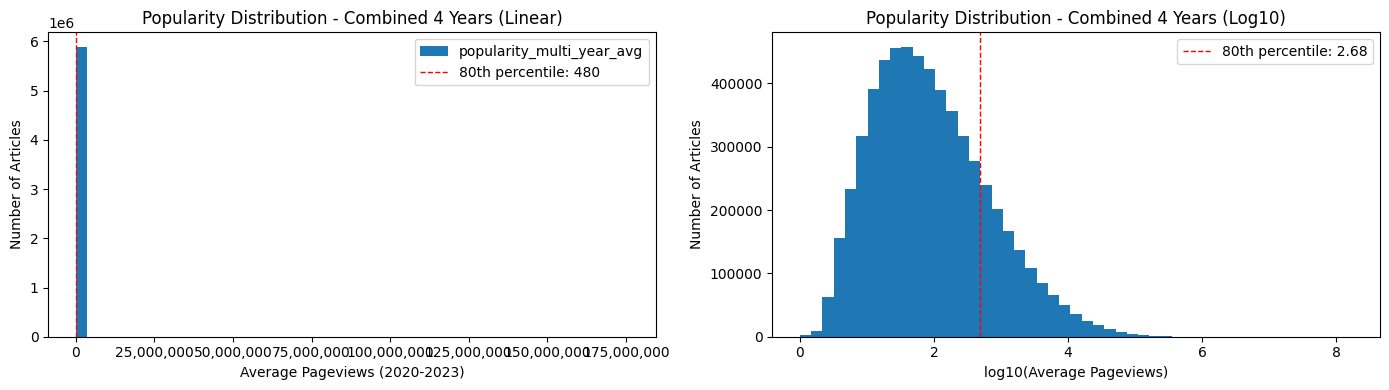

In [8]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import FuncFormatter

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Linear scale histogram
ax1 = axes[0]
result_df['popularity_multi_year_avg'].plot.hist(
    bins=50,
    ax=ax1,
    title=f"Popularity Distribution - Combined {len(YEARS)} Years (Linear)"
)
ax1.set_xlabel(f"Average Pageviews ({min(YEARS)}-{max(YEARS)})")
ax1.set_ylabel("Number of Articles")
percentile_80 = result_df['popularity_multi_year_avg'].quantile(0.8)
ax1.axvline(percentile_80, color='red', linestyle='dashed', linewidth=1, 
            label=f"80th percentile: {percentile_80:,.0f}")
ax1.legend()
ax1.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{int(x):,}"))

# Log scale histogram
ax2 = axes[1]
nonzero_pop = result_df['popularity_multi_year_avg'][result_df['popularity_multi_year_avg'] > 0]
log_pop = np.log10(nonzero_pop)
log_bins = np.linspace(log_pop.min(), log_pop.max(), 50)
ax2.hist(log_pop, bins=log_bins)
ax2.set_title(f"Popularity Distribution - Combined {len(YEARS)} Years (Log10)")
ax2.set_xlabel(f"log10(Average Pageviews)")
ax2.set_ylabel("Number of Articles")
percentile_80_log = np.log10(percentile_80) if percentile_80 > 0 else log_pop.min()
ax2.axvline(percentile_80_log, color='red', linestyle='dashed', linewidth=1, 
            label=f"80th percentile: {percentile_80_log:.2f}")
ax2.legend()

plt.tight_layout()
plt.show()

## Step 8: Save Combined Dataset

Save the final combined and averaged dataset to a parquet file.

In [9]:
import os

# Ensure output directory exists
OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)

# Save to parquet
result_df.to_parquet(OUTPUT_PATH, index=False)

print(f"✓ Saved combined dataset to: {OUTPUT_PATH}")
print(f"  File size: {os.path.getsize(OUTPUT_PATH) / 1e6:.1f} MB")
print(f"  Rows: {len(result_df):,}")
print(f"  Columns: {list(result_df.columns)}")

✓ Saved combined dataset to: /Users/cyro/Documents/VSC/PopularityBias/data/combined_all_years_popularity.parquet
  File size: 195.0 MB
  Rows: 5,903,530
  Columns: ['wikipedia_id', 'wikipedia_title', 'popularity_multi_year_avg', 'rank_multi_year_avg', 'years_count']


## Step 9: Prepare Dataset for HuggingFace Upload

Prepare the combined dataset for upload by renaming columns to match the standard format.

In [10]:
# Prepare upload DataFrame by renaming columns to match standard format
upload_df = result_df.copy()

# Rename columns to match single-year datasets
# Keep wikipedia_id and wikipedia_title as-is
# Rename multi_year_avg columns to standard avg columns
upload_df = upload_df.rename(columns={
    'popularity_multi_year_avg': 'popularity_avg',
    'rank_multi_year_avg': 'rank_avg'
})

# Keep the years_count column as metadata
print(f"Upload DataFrame shape: {upload_df.shape}")
print(f"Columns: {list(upload_df.columns)}")
display(upload_df.head())

Upload DataFrame shape: (5903530, 5)
Columns: ['wikipedia_id', 'wikipedia_title', 'popularity_avg', 'rank_avg', 'years_count']


,wikipedia_id,wikipedia_title,popularity_avg,rank_avg,years_count
0,1000,Hercule Poirot,75287.229167,1.129943e+04,4
1,10000,Eiffel,616.187500,1.010521e+06,4
2,10000001,Juan que reía,16.562500,4.523153e+06,4
3,10000009,La Noche del hurto,18.770833,4.389196e+06,4
4,1000001,NPU,1047.562500,7.363635e+05,4


## Step 10: Create README for HuggingFace

Create a comprehensive README file for the dataset card on HuggingFace.

In [11]:
# Create README content for HuggingFace dataset card
years_str = f"{min(YEARS)}-{max(YEARS)}"

README_TEXT = f"""---
license: mit
task_categories:
  - other
  - text-classification
language:
  - en
size_categories:
  - 1M<n<10M
tags:
  - wikipedia
  - pageviews
  - popularity
  - knowledge-graph
  - bias-detection
  - multi-year
---

# English Wikipedia Pageviews (Multi-Year Average {years_str})

This dataset combines Wikipedia article pageviews across multiple years ({", ".join(map(str, YEARS))}) into a single multi-year average. It provides more stable popularity metrics by averaging across years, reducing the impact of temporary spikes or trends.

## Dataset Description

This dataset was created by:
1. Downloading individual yearly datasets (`Cyro1/enwiki_pageviews_YEAR_m`)
2. Combining all years for each article
3. Calculating the mean popularity and rank across all available years

## Features

| Column | Type | Description |
|--------|------|-------------|
| `wikipedia_id` | int64 | Wikipedia article ID (page_id) |
| `wikipedia_title` | string | Wikipedia article title |
| `popularity_avg` | float64 | Average monthly pageviews across all years |
| `rank_avg` | float64 | Average rank across all years |
| `years_count` | int64 | Number of years this article appeared in (1-{len(YEARS)}) |

## Stats

- **Articles**: {len(upload_df):,} Wikipedia articles
- **Years Combined**: {", ".join(map(str, YEARS))}
- **Source**: Wikimedia pageview dumps, aggregated from yearly datasets
- **Split**: 90% train / 10% test (seed=42)

## Advantages of Multi-Year Averaging

- **Reduced variance**: Averages out seasonal variations and temporary events
- **More stable metrics**: Better represents long-term article importance
- **Robust to outliers**: Single-year spikes have less impact
- **Better for research**: More suitable for studying structural popularity bias

## Usage

```python
from datasets import load_dataset

# Load the multi-year dataset
ds = load_dataset("Cyro1/enwiki_pageviews_m")
df = ds["train"].to_pandas()

# Merge with your dataset
merged = your_df.merge(
    df[["wikipedia_id", "popularity_avg", "rank_avg", "years_count"]], 
    left_on="document_id", 
    right_on="wikipedia_id",
    how="left"
)

# Filter to articles present in all years for most stable metrics
stable_articles = df[df["years_count"] == {len(YEARS)}]
```

## Related Datasets

Individual yearly datasets are also available:
{chr(10).join(f"- [`Cyro1/enwiki_pageviews_{year}_m`](https://huggingface.co/datasets/Cyro1/enwiki_pageviews_{year}_m)" for year in YEARS)}

## Citation

If you use this dataset in your research, please cite the Wikimedia pageview dumps:

```
@misc{{wikimedia_pageviews,
  title = {{Wikimedia Downloads}},
  author = {{Wikimedia Foundation}},
  year = {{2024}},
  url = {{https://dumps.wikimedia.org/other/pageviews/}}
}}
```

## License

This dataset is released under the MIT license, following the terms of the Wikimedia pageview data.
"""

print("README created successfully!")
print(f"Length: {len(README_TEXT)} characters")

README created successfully!
Length: 3061 characters


## Step 11: Upload to HuggingFace

Convert to HuggingFace Dataset, create train/test split, and push to hub with README.

In [12]:
from huggingface_hub import HfApi, login
import datasets

# Authenticate with HuggingFace
print(f"Authenticating with HuggingFace...")
login(token=HF_TOKEN)

# Reset index and convert to HuggingFace dataset
# preserve_index=False ensures wikipedia_id is kept as a feature column
print(f"\nConverting to HuggingFace Dataset format...")
df_reset = upload_df.reset_index(drop=True)
dataset = datasets.Dataset.from_pandas(df_reset, preserve_index=False)

print(f"Dataset features: {dataset.features}")
print(f"Dataset size: {len(dataset):,} articles")

# Create train/test split
print(f"\nCreating train/test split (90/10)...")
dataset_dict = dataset.train_test_split(test_size=0.1, seed=42)
print(f"  Train: {len(dataset_dict['train']):,} articles")
print(f"  Test: {len(dataset_dict['test']):,} articles")

# Upload dataset
print(f"\n{'='*60}")
print(f"Uploading to HuggingFace: {HUGGINGFACE_REPO_ID}")
print(f"{'='*60}")
dataset_dict.push_to_hub(HUGGINGFACE_REPO_ID)

# Upload README
print(f"\nUploading README.md...")
api = HfApi()
api.upload_file(
    path_or_fileobj=README_TEXT.encode(),
    path_in_repo="README.md",
    repo_id=HUGGINGFACE_REPO_ID,
    repo_type="dataset",
    token=HF_TOKEN,
)

print(f"\n{'='*60}")
print(f"✓ Upload complete!")
print(f"{'='*60}")
print(f"📊 View your dataset at:")
print(f"   https://huggingface.co/datasets/{HUGGINGFACE_REPO_ID}")
print(f"\n💡 To use this dataset:")
print(f'   ds = load_dataset("{HUGGINGFACE_REPO_ID}")')

Authenticating with HuggingFace...

Converting to HuggingFace Dataset format...
Dataset features: {'wikipedia_id': Value(dtype='string', id=None), 'wikipedia_title': Value(dtype='string', id=None), 'popularity_avg': Value(dtype='float64', id=None), 'rank_avg': Value(dtype='float64', id=None), 'years_count': Value(dtype='int64', id=None)}
Dataset size: 5,903,530 articles

Creating train/test split (90/10)...
  Train: 5,313,177 articles
  Test: 590,353 articles

Uploading to HuggingFace: Cyro1/enwiki_pageviews_m


Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ?it/s]

Creating parquet from Arrow format:   0%|          | 0/5314 [00:00<?, ?ba/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

...

Creating parquet from Arrow format:   0%|          | 0/591 [00:00<?, ?ba/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

README.md:   0%|          | 0.00/24.0 [00:00<?, ?B/s]


Uploading README.md...

✓ Upload complete!
📊 View your dataset at:
   https://huggingface.co/datasets/Cyro1/enwiki_pageviews_m

💡 To use this dataset:
   ds = load_dataset("Cyro1/enwiki_pageviews_m")


## Summary

This notebook successfully:
1. Downloaded all yearly Wikipedia pageviews datasets from HuggingFace (`Cyro1/enwiki_pageviews_YEAR_m`)
2. Combined them into a single DataFrame
3. Calculated multi-year averages for both popularity and rank across all years
4. Visualized the distribution of popularity metrics
5. Saved the result to a local parquet file
6. **Uploaded the combined dataset to HuggingFace Hub at `Cyro1/enwiki_pageviews_m`**

## Dataset Columns

The final uploaded dataset contains:
- `wikipedia_id`: Wikipedia page ID
- `wikipedia_title`: Article title
- `popularity_avg`: Average pageviews across all years (renamed from popularity_multi_year_avg)
- `rank_avg`: Average rank across all years (renamed from rank_multi_year_avg)
- `years_count`: Number of years this article appeared in (1-4)

## Benefits of Multi-Year Dataset

Combining multiple years provides:
- **More stable metrics**: Reduces impact of temporary events or trends
- **Better bias analysis**: More reliable for studying structural popularity patterns
- **Robust statistics**: Averages out seasonal variations and outliers